# Signed Dominant-Mode Motif Overlap Operator

This notebook builds a motif-motif operator where each enumerated 3-node motif is one indexed unit. The edge between two motif units is positive or negative depending on whether their signed dominant-mode cell loadings align or oppose one another, and its magnitude is weighted by shared-cell Jaccard overlap and dominant eigenvalue strength.

## Literature basis and method note

I did not find a single publication that uses this exact hybrid operator for hippocampal 3-node motifs. The construction combines three established ideas:

- Benson, Gleich, and Leskovec's higher-order motif framework shows how small subgraphs can define motif-based adjacency/spectral analyses rather than ordinary edge-based analyses: https://pmc.ncbi.nlm.nih.gov/articles/PMC5133458/
- Signed network spectral work uses signed weighted adjacency spectra to characterize dynamics and balance/imbalance in networks with positive and negative interactions: https://arxiv.org/abs/2212.10158
- Signed eigenvector centrality uses the dominant eigenvector of a signed adjacency matrix, preserving sign information in node loadings: https://schochastics.github.io/signnet/reference/eigen_centrality_signed.html
- Jaccard overlap is a standard set/neighborhood similarity measure; in biological network similarity, it measures shared connected nodes relative to the union: https://pmc.ncbi.nlm.nih.gov/articles/PMC3959882/

Here, one motif occurrence is one unit. The operator entry between motif `k` and motif `l` is:

`A[k,l] = Jaccard(cells_k, cells_l) * dot(f_k, f_l)`

where `f_k` is an 85-cell signed feature vector with nonzero entries only for the three cells in motif `k`. Each nonzero entry is the oriented signed dominant eigenvector loading multiplied by `sqrt(abs(lambda_k))`.

## Configuration

The notebook consumes the Schur-ready 3x3 motif blocks exported by `motif_pathway_analysis.ipynb`. Those exports are source-to-target blocks: rows are presynaptic/source cell types and columns are postsynaptic/target cell types. This notebook transposes each 3x3 block once after loading, so dominant eigenvector loadings use the same convention as the global notebooks: rows are postsynaptic targets and columns are presynaptic sources. The no-self operator is the primary motif-enumeration view; the with-self operator restores diagonal weights later for comparison.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import motif_signed_overlap_analysis_script as analysis

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)

INPUT_DIR=Path("outputs/motif_pathway_analysis")
OUTPUT_DIR=Path("outputs/motif_signed_overlap_operator_analysis"); OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

NO_SELF_CSV=INPUT_DIR/"schur_ready_3x3_subnetworks_without_self.csv"
NO_SELF_NPZ=INPUT_DIR/"schur_ready_3x3_subnetworks_without_self.npz"
WITH_SELF_CSV=INPUT_DIR/"schur_ready_3x3_subnetworks_with_self.csv"
WITH_SELF_NPZ=INPUT_DIR/"schur_ready_3x3_subnetworks_with_self.npz"

N_MODES=12
N_LAPLACIAN_MODES=8
EIGENVALUE_POWER=0.5
TRANSPOSE_SOURCE_TARGET_BLOCKS=True



## Load motif blocks and abbreviate cell names

Rows are motif occurrences. The acronym table is used only for readable displays and exports; full cell-type names are preserved.

In [2]:
meta_no,blocks_no=analysis.load_blocks_and_metadata(NO_SELF_CSV,NO_SELF_NPZ)
meta_self,blocks_self=analysis.load_blocks_and_metadata(WITH_SELF_CSV,WITH_SELF_NPZ)
if TRANSPOSE_SOURCE_TARGET_BLOCKS:
    blocks_no=blocks_no.transpose(0,2,1)
    blocks_self=blocks_self.transpose(0,2,1)
BLOCK_ORIENTATION="rows=postsynaptic target, columns=presynaptic source"
all_cell_types=pd.concat([meta_no[["node_1","node_2","node_3"]].stack(),meta_self[["node_1","node_2","node_3"]].stack()],ignore_index=True)
acronym_map=analysis.make_acronym_map(all_cell_types)
acronyms=analysis.acronym_table(acronym_map)
print("no-self blocks:",blocks_no.shape)
print("with-self blocks:",blocks_self.shape)
print("block orientation used for analysis:",BLOCK_ORIENTATION)
display(acronyms.head(20))

no-self blocks: (39141, 3, 3)
with-self blocks: (39141, 3, 3)


,cell_type,cell_type_acronym
0,CA1 Axo Axonic,CA1-AxAxo
1,CA1 Back Projection,CA1-BackProj
2,CA1 Basket,CA1-Bas
3,CA1 Basket CCK+,CA1-BasCCK
4,CA1 Bistratified,CA1-Bi
5,CA1 Horizontal Axo Axonic,CA1-HorAxAxo
6,CA1 Horizontal Basket,CA1-HorBas
7,CA1 Ivy,CA1-Ivy
8,CA1 LMR,CA1-LMR
9,CA1 Neurogliaform,CA1-NGF


## Compute signed dominant-mode vectors

For each 3x3 motif block, this section extracts the dominant eigenpair. Eigenvector signs/phases are oriented consistently by making the largest-magnitude component positive. These signed node loadings are the local cell-type roles inside each motif.

In [3]:
mode_table_no=analysis.signed_dominant_mode_table(meta_no,blocks_no,"without_self",acronym_map=acronym_map)
mode_table_self=analysis.signed_dominant_mode_table(meta_self,blocks_self,"with_self",acronym_map=acronym_map)
preview_columns=["motif_index","motif_acronym","superpattern","dominant_eigenvalue_abs","signed_loading_1","signed_loading_2","signed_loading_3","dominant_signed_node_acronym"]
display(mode_table_no.head(15)[preview_columns])

,motif_index,motif_acronym,superpattern,dominant_eigenvalue_abs,signed_loading_1,signed_loading_2,signed_loading_3,dominant_signed_node_acronym
0,0,DG-Gr | DG-AIPRIM | DG-HICAP,M,0.463914,1.000000,-9.778962e-05,-0.000075,DG-Gr
1,1,DG-Gr | DG-AIPRIM | DG-MOLAX,M,0.492466,0.999999,-1.150679e-03,-0.001060,DG-Gr
2,2,DG-Gr | DG-AIPRIM | DG-TotMolLay,M,0.495287,0.999994,-7.835800e-04,-0.003479,DG-Gr
3,3,DG-Gr | DG-AIPRIM | DG-HIPROM,M,0.461860,1.000000,-7.965603e-07,-0.000018,DG-Gr
4,4,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-SupMIN,M,0.687854,0.928963,-3.701682e-01,0.001717,EC-LI/II-MP
5,5,DG-Gr | DG-AIPRIM | DG-HIP,M,0.474215,0.999998,-4.667048e-05,-0.002219,DG-Gr
6,6,DG-Gr | DG-AIPRIM | DG-AxAxo,L,0.472782,1.000000,-2.598214e-04,0.000013,DG-Gr
7,7,CA3-P | CA1-BackProj | CA1-TriLam,L,0.286473,0.999996,2.730631e-03,-0.000747,CA3-P
8,8,DG-Gr | DG-AIPRIM | DG-Bas,L,0.499262,0.999997,-1.806576e-03,0.001392,DG-Gr
9,9,EC-LI/II-MP | MEC-LIII-SupMIN | MEC-LIII-SupTriIN,M,0.291147,0.999994,-4.231372e-04,-0.003472,EC-LI/II-MP


## Build sparse signed Jaccard motif-motif operators

This is the square motif-index operator. Its shape is `39141 x 39141`, but it is stored sparsely: entries are nonzero only for motif pairs sharing at least one cell type and having nonzero signed-mode dot product.

In [4]:
operator_no,signed_features_no,membership_no,cell_types_no=analysis.build_signed_jaccard_operator(mode_table_no,eigenvalue_power=EIGENVALUE_POWER)
operator_self,signed_features_self,membership_self,cell_types_self=analysis.build_signed_jaccard_operator(mode_table_self,eigenvalue_power=EIGENVALUE_POWER)
operator_summary=pd.DataFrame([
    {"scenario":"without_self","shape":str(operator_no.shape),"nonzero_entries":operator_no.nnz,"density":operator_no.nnz/(operator_no.shape[0]*operator_no.shape[1]),"min_value":operator_no.data.min(),"max_value":operator_no.data.max()},
    {"scenario":"with_self","shape":str(operator_self.shape),"nonzero_entries":operator_self.nnz,"density":operator_self.nnz/(operator_self.shape[0]*operator_self.shape[1]),"min_value":operator_self.data.min(),"max_value":operator_self.data.max()},
])
display(operator_summary)

,scenario,shape,nonzero_entries,density,min_value,max_value
0,without_self,"(39141, 39141)",54259785,0.035417,-0.148569,0.827766
1,with_self,"(39141, 39141)",79755269,0.052059,-0.058749,0.910179


## Decompose signed motif-motif operators

The operator is symmetric, so the leading eigenvectors are also the Schur vectors for this operator. Each mode contains many motif indices with positive or negative loadings: same-sign motifs are aligned signed pathway neighborhoods; opposite-sign motifs are anti-aligned neighborhoods.

,mode,operator_eigenvalue,operator_eigenvalue_abs,positive_motif_count,negative_motif_count,top_motif_index,top_motif_acronym,top_superpattern,top_loading
0,1,46.077150,46.077150,15392,15757,17,EC-LI/II-MP | MEC-LII-St | EC-LII/III-PT,M,-0.093314
1,2,36.027516,36.027516,15159,15990,18,DG-Gr | DG-Mossy | DG-AIPRIM,M,0.075894
2,3,24.783021,24.783021,16220,14929,351,DG-Gr | CA3c-P | CA2-P,L,0.101992
3,4,23.479622,23.479622,14694,16455,47,CA3-P | CA3-Bas | CA1-BackProj,L,0.072162
4,5,15.232811,15.232811,15947,15202,330,EC-LI/II-MP | EC-LI/II-PFan | MEC-LII-St,M,0.073973
5,6,12.274842,12.274842,12214,18935,78,EC-LI/II-MP | EC-LI/II-PFan | EC-LII/III-PT,M,-0.126528
6,7,12.264376,12.264376,15591,15558,498,CA1-P | CA1-BasCCK | CA1-TriLam,L,0.069555
7,8,10.794696,10.794696,12593,18556,127,DG-Gr | DG-Mossy | DG-Bas,L,-0.080081
8,9,10.281904,10.281904,13580,17569,894,MEC-LII-St | MEC-LIII-CxP | MEC-LIII-SupMIN,M,0.073901
9,10,8.215589,8.215589,14682,16467,4,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-SupMIN,M,-0.108080


,mode,operator_eigenvalue,operator_eigenvalue_abs,positive_motif_count,negative_motif_count,top_motif_index,top_motif_acronym,top_superpattern,top_loading
0,1,192.441736,192.441736,13609,25518,17,EC-LI/II-MP | MEC-LII-St | EC-LII/III-PT,M,-0.035476
1,2,51.026008,51.026008,16206,22921,159,CA3-P | CA3c-P | CA2-P,M,-0.038866
2,3,36.854989,36.854989,19421,19706,5588,CA1-P | CA1-SUBProP | EC-LIV/VI-DeeMPr,J,0.026828
3,4,32.381807,32.381807,16553,22574,567,EC-LII/III-PT | MEC-LIII-SupMIN | MEC-LIII-SupTriIN,M,-0.035021
4,5,30.592800,30.592800,21689,17438,182,CA3c-P | CA2-P | CA1-P,K,0.033190
5,6,30.113469,30.113469,19327,19800,14963,MEC-LII-OblP | EC-LIII-P | MEC-LIII-SupMIN,L,-0.038196
6,7,22.689279,22.689279,25356,13771,351,DG-Gr | CA3c-P | CA2-P,L,-0.068882
7,8,21.091806,21.091806,26804,12323,8,DG-Gr | DG-AIPRIM | DG-Bas,L,0.062431
8,9,20.569672,20.569672,20524,18603,330,EC-LI/II-MP | EC-LI/II-PFan | MEC-LII-St,M,0.078501
9,10,19.806793,19.806793,19200,19927,78,EC-LI/II-MP | EC-LI/II-PFan | EC-LII/III-PT,M,0.140874


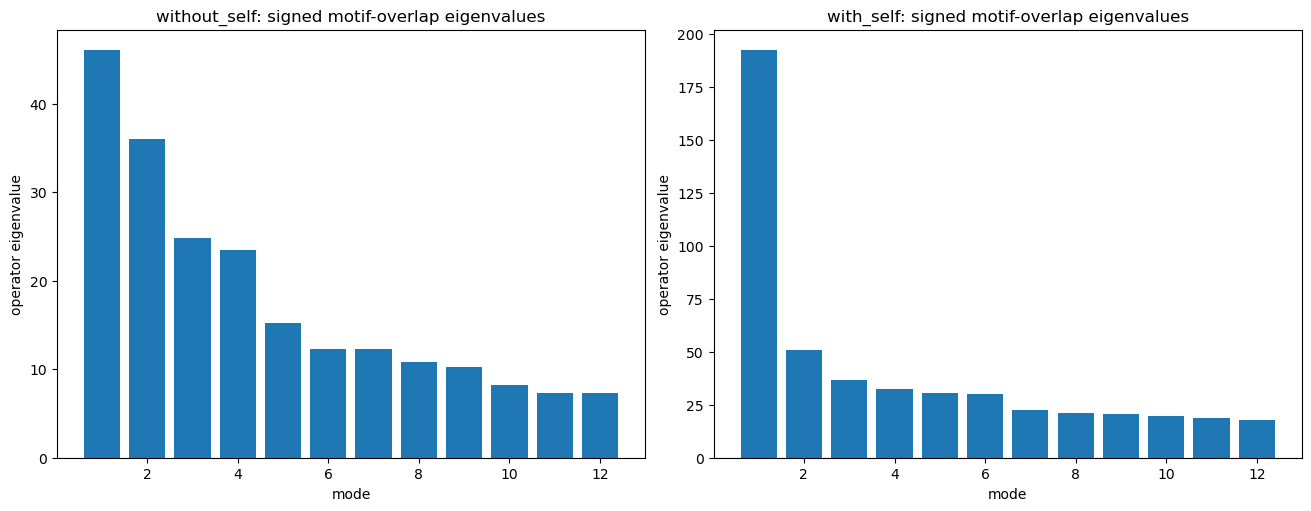

In [5]:
decomp_no=analysis.decompose_signed_operator(operator_no,mode_table_no,n_modes=N_MODES)
decomp_self=analysis.decompose_signed_operator(operator_self,mode_table_self,n_modes=N_MODES)
display(decomp_no["modes"])
display(decomp_self["modes"])
fig,axes=plt.subplots(1,2,figsize=(13,5),constrained_layout=True)
for title,decomp,ax in [("without_self",decomp_no,axes[0]),("with_self",decomp_self,axes[1])]:
    values=decomp["modes"]["operator_eigenvalue"]
    ax.bar(range(1,len(values)+1),values)
    ax.axhline(0,color="0.5",linewidth=0.8)
    ax.set(title=f"{title}: signed motif-overlap eigenvalues",xlabel="mode",ylabel="operator eigenvalue")
plt.show()

## Signed Laplacian decomposition of motif neighborhoods

Because negative weights in this matrix represent inhibitory signaling, the biologically appropriate Laplacian is the signed normalized Laplacian: `L = I - D_abs^(-1/2) A D_abs^(-1/2)`, where `D_abs` uses the sum of absolute signed motif-motif weights. This preserves excitatory/inhibitory alignment and opposition. An ordinary nonnegative Laplacian on `abs(A)` would be a structural control analysis, but it is not the default here because it discards inhibitory sign.


,scenario,laplacian_kind,mode,laplacian_eigenvalue,top_motif_index,top_motif_acronym,top_superpattern,top_loading
0,without_self,signed_normalized,1,0.007695,498,CA1-P | CA1-BasCCK | CA1-TriLam,L,-0.043774
1,without_self,signed_normalized,2,0.015623,37594,DG-HilEctGr | DG-AxAxo | CA3-BasCCK,F,0.128283
2,without_self,signed_normalized,3,0.022638,47,CA3-P | CA3-Bas | CA1-BackProj,L,-0.043215
3,without_self,signed_normalized,4,0.028066,3447,CA3-Bas | CA3-BasCCK | CA3-MossyFibAss.2,M,-0.109177
4,without_self,signed_normalized,5,0.032861,8,DG-Gr | DG-AIPRIM | DG-Bas,L,-0.044674
5,without_self,signed_normalized,6,0.048348,17,EC-LI/II-MP | MEC-LII-St | EC-LII/III-PT,M,-0.049901
6,without_self,signed_normalized,7,0.063509,15783,CA3c-P | MEC-LIII-SupMIN | MEC-LIII-SupTriIN,-A,0.096604
7,without_self,signed_normalized,8,0.068162,10421,CA1-RadG | CA1-BasCCK | CA1-TriLam,L,-0.051553
8,with_self,signed_normalized,1,0.001230,17,EC-LI/II-MP | MEC-LII-St | EC-LII/III-PT,M,-0.020478
9,with_self,signed_normalized,2,0.006974,17,EC-LI/II-MP | MEC-LII-St | EC-LII/III-PT,M,-0.019443


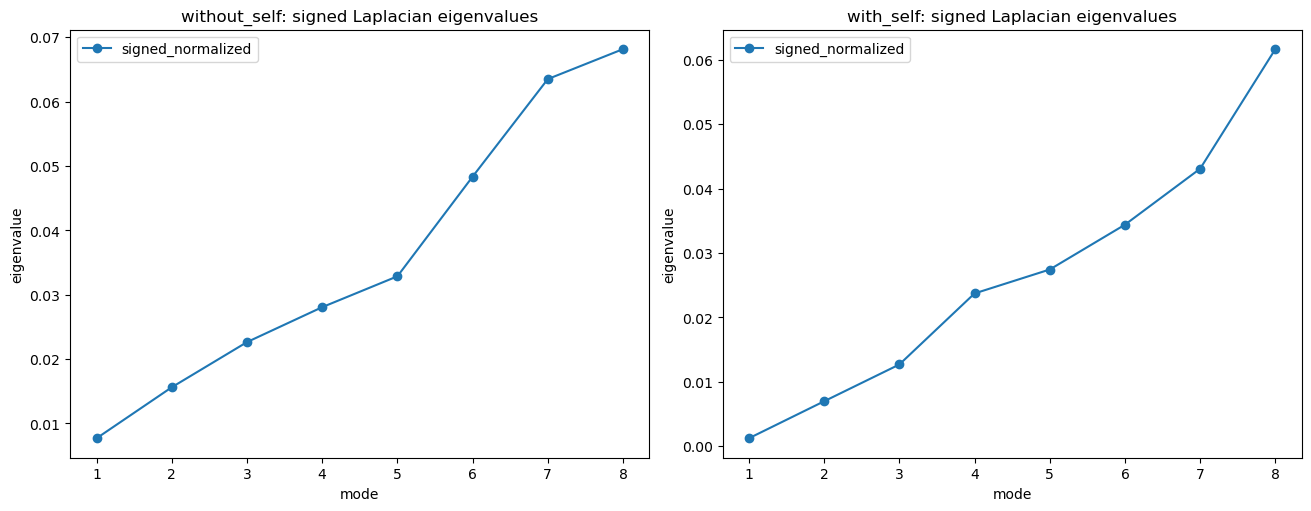

In [6]:
lap_signed_no=analysis.decompose_laplacian(operator_no,mode_table_no,kind="signed_normalized",n_modes=N_LAPLACIAN_MODES)
lap_signed_self=analysis.decompose_laplacian(operator_self,mode_table_self,kind="signed_normalized",n_modes=N_LAPLACIAN_MODES)
laplacian_mode_summary=pd.concat([
    lap_signed_no["modes"].assign(scenario="without_self"),
    lap_signed_self["modes"].assign(scenario="with_self"),
],ignore_index=True)
display(laplacian_mode_summary[["scenario","laplacian_kind","mode","laplacian_eigenvalue","top_motif_index","top_motif_acronym","top_superpattern","top_loading"]])
fig,axes=plt.subplots(1,2,figsize=(13,5),constrained_layout=True)
for scenario,ax in [("without_self",axes[0]),("with_self",axes[1])]:
    plot=laplacian_mode_summary[laplacian_mode_summary.scenario==scenario]
    ax.plot(plot["mode"],plot["laplacian_eigenvalue"],marker="o",label="signed_normalized")
    ax.set(title=f"{scenario}: signed Laplacian eigenvalues",xlabel="mode",ylabel="eigenvalue")
    ax.legend()
plt.show()


## Signed Laplacian motif participation and cell summaries

Small signed-Laplacian eigenvectors describe smooth signed motif neighborhoods. Motifs with similar excitatory/inhibitory role structure tend to share the same sign in a mode; motifs with opposed signed roles can appear with the opposite sign. Each mode is therefore a distributed signed module across many indexed motifs.


In [7]:
lap_cell_signed_no=analysis.summarize_mode_cells(lap_signed_no["motif_participation"].rename(columns={"laplacian_loading":"mode_loading","abs_laplacian_loading":"abs_mode_loading"}),mode_table_no,top_n=50)
lap_cell_signed_self=analysis.summarize_mode_cells(lap_signed_self["motif_participation"].rename(columns={"laplacian_loading":"mode_loading","abs_laplacian_loading":"abs_mode_loading"}),mode_table_self,top_n=50)
print("Top motif participants: no-self signed normalized Laplacian")
display(lap_signed_no["motif_participation"].query("mode <= 3 and rank <= 12"))
print("Top cell summaries: no-self signed normalized Laplacian")
display(lap_cell_signed_no.query("mode <= 3").groupby("mode",group_keys=False).head(10))
print("Top motif participants: with-self signed normalized Laplacian")
display(lap_signed_self["motif_participation"].query("mode <= 3 and rank <= 12"))
print("Top cell summaries: with-self signed normalized Laplacian")
display(lap_cell_signed_self.query("mode <= 3").groupby("mode",group_keys=False).head(10))


Top motif participants: no-self signed normalized Laplacian


,laplacian_kind,mode,rank,motif_index,motif_acronym,nodes,superpattern,dominant_eigenvalue_abs,laplacian_loading,abs_laplacian_loading,operator_abs_degree
0,signed_normalized,1,1,498,CA1-P | CA1-BasCCK | CA1-TriLam,CA1 Pyramidal | CA1 Basket CCK+ | CA1 Trilaminar,L,0.155078,-0.043774,0.043774,25.080832
1,signed_normalized,1,2,392,CA1-P | CA1-Bas | CA1-TriLam,CA1 Pyramidal | CA1 Basket | CA1 Trilaminar,L,0.142157,-0.042648,0.042648,23.680077
2,signed_normalized,1,3,289,CA1-P | CA1-HorBas | CA1-TriLam,CA1 Pyramidal | CA1 Horizontal Basket | CA1 Trilaminar,L,0.140168,-0.042607,0.042607,23.541615
3,signed_normalized,1,4,147,CA1-P | CA1-BackProj | CA1-TriLam,CA1 Pyramidal | CA1 Back Projection | CA1 Trilaminar,M,0.133388,-0.041907,0.041907,22.799365
4,signed_normalized,1,5,939,CA1-P | CA1-HorBas | CA1-BasCCK,CA1 Pyramidal | CA1 Horizontal Basket | CA1 Basket CCK+,M,0.122474,-0.040822,0.040822,21.777773
5,signed_normalized,1,6,154,CA1-P | CA1-Bi | CA1-TriLam,CA1 Pyramidal | CA1 Bistratified | CA1 Trilaminar,M,0.121672,-0.040498,0.040498,21.316707
6,signed_normalized,1,7,1733,CA1-P | CA1-Bas | CA1-BasCCK,CA1 Pyramidal | CA1 Basket | CA1 Basket CCK+,M,0.117725,-0.040184,0.040184,21.436965
7,signed_normalized,1,8,2097,CA1-P | CA1-BackProj | CA1-BasCCK,CA1 Pyramidal | CA1 Back Projection | CA1 Basket CCK+,L,0.117113,-0.040108,0.040108,21.221627
8,signed_normalized,1,9,132,CA1-P | CA1-SOSO | CA1-TriLam,CA1 Pyramidal | CA1 SO SO | CA1 Trilaminar,M,0.117850,-0.039889,0.039889,20.640640
9,signed_normalized,1,10,155,CA1-P | CA1-Ivy | CA1-TriLam,CA1 Pyramidal | CA1 Ivy | CA1 Trilaminar,M,0.117230,-0.039768,0.039768,20.560637


Top cell summaries: no-self signed normalized Laplacian


,mode,cell_type,cell_type_acronym,total_signed_contribution,total_abs_contribution,motif_mentions
0,1,CA1 Pyramidal,CA1-P,-1.968113,1.968113,50
1,1,CA1 Basket CCK+,CA1-BasCCK,0.000008,0.003413,4
2,1,CA1 Horizontal Basket,CA1-HorBas,0.001510,0.001803,4
3,1,CA1 Basket,CA1-Bas,0.000569,0.001535,3
4,1,CA1 Back Projection,CA1-BackProj,0.001387,0.001387,3
5,1,CA1 Trilaminar,CA1-TriLam,0.000667,0.000706,45
6,1,CA1 Ivy,CA1-Ivy,0.000223,0.000223,1
7,1,CA1 Bistratified,CA1-Bi,0.000191,0.000191,1
8,1,CA1 SO SO,CA1-SOSO,0.000132,0.000132,1
9,1,CA1 Oriens Alveus,CA1-OriAlv,0.000117,0.000117,1


Top motif participants: with-self signed normalized Laplacian


,laplacian_kind,mode,rank,motif_index,motif_acronym,nodes,superpattern,dominant_eigenvalue_abs,laplacian_loading,abs_laplacian_loading,operator_abs_degree
0,signed_normalized,1,1,17,EC-LI/II-MP | MEC-LII-St | EC-LII/III-PT,EC LI II Multipolar Pyramidal | MEC LII Stellate | EC LII III Pyramidal Tripolar,M,0.910179,-0.020478,0.020478,259.771241
1,signed_normalized,1,2,78,EC-LI/II-MP | EC-LI/II-PFan | EC-LII/III-PT,EC LI II Multipolar Pyramidal | EC LI II Pyramidal Fan | EC LII III Pyramidal Tripolar,M,0.896489,-0.020358,0.020358,258.974591
2,signed_normalized,1,3,29,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-CxP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LIII Complex Pyramidal,M,0.879460,-0.020272,0.020272,254.250530
3,signed_normalized,1,4,27,EC-LI/II-MP | EC-LII/III-PT | LEC-LIII-CxP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | LEC LIII Complex Pyramidal,M,0.874254,-0.020212,0.020212,252.453859
4,signed_normalized,1,5,39,EC-LI/II-MP | EC-LII/III-PT | LEC-LIII-MPr,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | LEC LIII Multipolar Principal,M,0.874033,-0.020212,0.020212,252.467909
5,signed_normalized,1,6,19,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-BipCxP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LIII Bipolar Complex Pyramidal,M,0.871566,-0.020189,0.020189,251.786456
6,signed_normalized,1,7,20,EC-LI/II-MP | MEC-LII/III-PMul | EC-LII/III-PT,EC LI II Multipolar Pyramidal | MEC LII III Pyramidal Multiform | EC LII III Pyramidal Tripolar,M,0.870425,-0.020183,0.020183,251.683354
7,signed_normalized,1,8,44,EC-LI/II-MP | EC-LII/III-PT | MEC-LV-P,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LV Pyramidal,M,0.868350,-0.020182,0.020182,251.854387
8,signed_normalized,1,9,41,EC-LI/II-MP | EC-LII/III-PT | MEC-LV-SupP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LV Superficial Pyramidal,M,0.866929,-0.020158,0.020158,251.025034
9,signed_normalized,1,10,22,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-SupTriIN,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LIII Superficial Trilayered Interneuron,M,0.861770,-0.020125,0.020125,250.209019


Top cell summaries: with-self signed normalized Laplacian


,mode,cell_type,cell_type_acronym,total_signed_contribution,total_abs_contribution,motif_mentions
0,1,EC LI II Multipolar Pyramidal,EC-LI/II-MP,-0.967754,0.967754,50
1,1,EC LII III Pyramidal Tripolar,EC-LII/III-PT,-0.188465,0.188465,50
2,1,EC LI II Pyramidal Fan,EC-LI/II-PFan,-0.006165,0.006165,1
3,1,MEC LII Stellate,MEC-LII-St,-0.001063,0.001063,1
4,1,MEC LIII Complex Pyramidal,MEC-LIII-CxP,-0.000508,0.000508,1
5,1,LEC LIII Multipolar Principal,LEC-LIII-MPr,-0.000504,0.000504,1
6,1,MEC LV Pyramidal,MEC-LV-P,-0.000356,0.000356,1
7,1,LEC LIII Complex Pyramidal,LEC-LIII-CxP,-0.000268,0.000268,1
8,1,MEC LIII Superficial Trilayered Interneuron,MEC-LIII-SupTriIN,0.000111,0.000111,1
9,1,MEC LII III Pyramidal Multiform,MEC-LII/III-PMul,-0.000103,0.000103,1


## Enumerated motif participation in leading modes

These tables show the top indexed motifs participating in the leading signed operator modes. A mode is a distributed pattern over many motifs, not a single motif.

In [8]:
print("Top motif participants, no-self")
display(decomp_no["motif_participation"].query("mode <= 3 and rank <= 15"))
print("Top motif participants, with-self")
display(decomp_self["motif_participation"].query("mode <= 3 and rank <= 15"))

Top motif participants, no-self


,mode,rank,motif_index,motif_acronym,nodes,superpattern,dominant_eigenvalue_abs,mode_loading,abs_mode_loading
0,1,1,17,EC-LI/II-MP | MEC-LII-St | EC-LII/III-PT,EC LI II Multipolar Pyramidal | MEC LII Stellate | EC LII III Pyramidal Tripolar,M,0.827766,-0.093314,0.093314
1,1,2,29,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-CxP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LIII Complex Pyramidal,M,0.740979,-0.082789,0.082789
2,1,3,27,EC-LI/II-MP | EC-LII/III-PT | LEC-LIII-CxP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | LEC LIII Complex Pyramidal,M,0.728986,-0.080969,0.080969
3,1,4,39,EC-LI/II-MP | EC-LII/III-PT | LEC-LIII-MPr,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | LEC LIII Multipolar Principal,M,0.726138,-0.080890,0.080890
4,1,5,19,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-BipCxP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LIII Bipolar Complex Pyramidal,M,0.719044,-0.080093,0.080093
5,1,6,20,EC-LI/II-MP | MEC-LII/III-PMul | EC-LII/III-PT,EC LI II Multipolar Pyramidal | MEC LII III Pyramidal Multiform | EC LII III Pyramidal Tripolar,M,0.717057,-0.079419,0.079419
6,1,7,44,EC-LI/II-MP | EC-LII/III-PT | MEC-LV-P,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LV Pyramidal,M,0.710753,-0.077893,0.077893
7,1,8,67,EC-LI/II-MP | EC-LII/III-PT | EC-LIII-PSt,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | EC LIII Pyramidal Stellate,L,0.712607,-0.076953,0.076953
8,1,9,41,EC-LI/II-MP | EC-LII/III-PT | MEC-LV-SupP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LV Superficial Pyramidal,M,0.706597,-0.076851,0.076851
9,1,10,81,EC-LI/II-MP | EC-LII/III-PT | EC-LIII/V-BipP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | EC LIII V Bipolar Pyramidal,L,0.709209,-0.076753,0.076753


Top motif participants, with-self


,mode,rank,motif_index,motif_acronym,nodes,superpattern,dominant_eigenvalue_abs,mode_loading,abs_mode_loading
0,1,1,17,EC-LI/II-MP | MEC-LII-St | EC-LII/III-PT,EC LI II Multipolar Pyramidal | MEC LII Stellate | EC LII III Pyramidal Tripolar,M,0.910179,-0.035476,0.035476
1,1,2,29,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-CxP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LIII Complex Pyramidal,M,0.879460,-0.034725,0.034725
2,1,3,27,EC-LI/II-MP | EC-LII/III-PT | LEC-LIII-CxP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | LEC LIII Complex Pyramidal,M,0.874254,-0.034599,0.034599
3,1,4,39,EC-LI/II-MP | EC-LII/III-PT | LEC-LIII-MPr,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | LEC LIII Multipolar Principal,M,0.874033,-0.034594,0.034594
4,1,5,19,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-BipCxP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LIII Bipolar Complex Pyramidal,M,0.871566,-0.034540,0.034540
5,1,6,20,EC-LI/II-MP | MEC-LII/III-PMul | EC-LII/III-PT,EC LI II Multipolar Pyramidal | MEC LII III Pyramidal Multiform | EC LII III Pyramidal Tripolar,M,0.870425,-0.034505,0.034505
6,1,7,44,EC-LI/II-MP | EC-LII/III-PT | MEC-LV-P,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LV Pyramidal,M,0.868350,-0.034446,0.034446
7,1,8,41,EC-LI/II-MP | EC-LII/III-PT | MEC-LV-SupP,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LV Superficial Pyramidal,M,0.866929,-0.034414,0.034414
8,1,9,22,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-SupTriIN,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LIII Superficial Trilayered Interneuron,M,0.861770,-0.034276,0.034276
9,1,10,4,EC-LI/II-MP | EC-LII/III-PT | MEC-LIII-SupMIN,EC LI II Multipolar Pyramidal | EC LII III Pyramidal Tripolar | MEC LIII Superficial Multipolar Interneuron,M,0.842018,-0.033777,0.033777


## Cell-type summaries of motif modes

This section summarizes which cell types recur in the top motif participants of each signed operator mode, preserving whether their signed loadings align positively or negatively with the mode.

In [9]:
cell_summary_no=analysis.summarize_mode_cells(decomp_no["motif_participation"],mode_table_no,top_n=50)
cell_summary_self=analysis.summarize_mode_cells(decomp_self["motif_participation"],mode_table_self,top_n=50)
print("No-self mode-cell summary")
display(cell_summary_no.query("mode <= 3").groupby("mode",group_keys=False).head(12))
print("With-self mode-cell summary")
display(cell_summary_self.query("mode <= 3").groupby("mode",group_keys=False).head(12))

No-self mode-cell summary


,mode,cell_type,cell_type_acronym,total_signed_contribution,total_abs_contribution,motif_mentions
0,1,EC LI II Multipolar Pyramidal,EC-LI/II-MP,-3.612317e+00,3.612317e+00,50
1,1,EC LII III Pyramidal Tripolar,EC-LII/III-PT,-1.375704e+00,1.375704e+00,50
2,1,MEC LII Stellate,MEC-LII-St,-9.848559e-03,9.848559e-03,1
3,1,LEC LIII Multipolar Principal,LEC-LIII-MPr,-4.379048e-03,4.379048e-03,1
4,1,MEC LIII Complex Pyramidal,MEC-LIII-CxP,-4.089457e-03,4.089457e-03,1
5,1,MEC LV Pyramidal,MEC-LV-P,-2.899337e-03,2.899337e-03,1
6,1,LEC LIII Complex Pyramidal,LEC-LIII-CxP,-2.541766e-03,2.541766e-03,1
7,1,MEC LII III Pyramidal Multiform,MEC-LII/III-PMul,-9.422683e-04,9.422683e-04,1
8,1,MEC LIII Bipolar Complex Pyramidal,MEC-LIII-BipCxP,-8.712178e-04,8.712178e-04,1
9,1,EC LIII V Bipolar Pyramidal,EC-LIII/V-BipP,-8.404051e-04,8.404051e-04,1


With-self mode-cell summary


,mode,cell_type,cell_type_acronym,total_signed_contribution,total_abs_contribution,motif_mentions
0,1,EC LI II Multipolar Pyramidal,EC-LI/II-MP,-1.614727,1.614727,50
1,1,EC LII III Pyramidal Tripolar,EC-LII/III-PT,-0.314458,0.314458,50
2,1,EC LI II Pyramidal Fan,EC-LI/II-PFan,-0.010210,0.010210,1
3,1,MEC LII Stellate,MEC-LII-St,-0.001842,0.001842,1
4,1,MEC LIII Complex Pyramidal,MEC-LIII-CxP,-0.000871,0.000871,1
5,1,LEC LIII Multipolar Principal,LEC-LIII-MPr,-0.000862,0.000862,1
6,1,MEC LV Pyramidal,MEC-LV-P,-0.000608,0.000608,1
7,1,LEC LIII Complex Pyramidal,LEC-LIII-CxP,-0.000459,0.000459,1
8,1,MEC LIII Superficial Trilayered Interneuron,MEC-LIII-SupTriIN,0.000190,0.000190,1
9,1,MEC LII III Pyramidal Multiform,MEC-LII/III-PMul,-0.000176,0.000176,1


## Export results

The square motif-motif operators are exported as sparse `.npz` files. Mode tables and participation summaries are exported as CSV files for inspection.

In [10]:
analysis.export_signed_overlap_results(OUTPUT_DIR,"without_self",mode_table_no,operator_no,decomp_no,cell_summary_no)
analysis.export_signed_overlap_results(OUTPUT_DIR,"with_self",mode_table_self,operator_self,decomp_self,cell_summary_self)
operator_summary.to_csv(OUTPUT_DIR/"signed_jaccard_operator_summary.csv",index=False)
laplacian_mode_summary.to_csv(OUTPUT_DIR/"signed_laplacian_mode_summary.csv",index=False)
analysis.export_laplacian_results(OUTPUT_DIR,"without_self","signed_normalized",lap_signed_no,lap_cell_signed_no)
analysis.export_laplacian_results(OUTPUT_DIR,"with_self","signed_normalized",lap_signed_self,lap_cell_signed_self)
acronyms.to_csv(OUTPUT_DIR/"cell_type_acronym_map.csv",index=False)
for path in sorted(OUTPUT_DIR.iterdir()):
    print(path.resolve())


/Users/raniceto/Documents/Hippocampome/outputs/motif_signed_overlap_operator_analysis/cell_type_acronym_map.csv
/Users/raniceto/Documents/Hippocampome/outputs/motif_signed_overlap_operator_analysis/signed_jaccard_operator_summary.csv
/Users/raniceto/Documents/Hippocampome/outputs/motif_signed_overlap_operator_analysis/signed_laplacian_mode_summary.csv
/Users/raniceto/Documents/Hippocampome/outputs/motif_signed_overlap_operator_analysis/with_self_signed_dominant_mode_table.csv
/Users/raniceto/Documents/Hippocampome/outputs/motif_signed_overlap_operator_analysis/with_self_signed_jaccard_operator.npz
/Users/raniceto/Documents/Hippocampome/outputs/motif_signed_overlap_operator_analysis/with_self_signed_normalized_laplacian.npz
/Users/raniceto/Documents/Hippocampome/outputs/motif_signed_overlap_operator_analysis/with_self_signed_normalized_laplacian_cell_summary.csv
/Users/raniceto/Documents/Hippocampome/outputs/motif_signed_overlap_operator_analysis/with_self_signed_normalized_laplacian_de

## Interpretation guide

A positive motif-motif value means two indexed motifs share cell types whose signed dominant-mode roles are aligned. A negative value means they share cell types but those signed roles oppose each other. In this dataset, negative sign has biological meaning as inhibitory signaling, so the signed normalized Laplacian is the primary module analysis. Leading signed-Laplacian modes identify motif neighborhoods organized by excitatory/inhibitory alignment and opposition, rather than ordinary unsigned structural similarity.
